<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Modeling Workflow (Walkthrough) - Solution

---

### About
Model data from scratch: gather data, clean it, explore it, and then evaluate several models.

### Learning Objectives
- Gather, clean, explore and model a dataset from scratch.
- Split data into testing and training sets using both train/test split and cross-validation and apply both techniques to score a model.
- Evaluate several models.


### Notebook Guide

- Importing libaries
- Load the Data
- Data Cleaning:
     - Initial check
     - Clean up PhD column
     - Drop `NaN`s
- Feature engineering: Binarize `Private` column
- EDA:
     - `apps`
     - What else do we want to explore?
     - Create Histograms of All Numerical Columns
     - Plot a Heatmap of the Correlation Matrix
     - Use seaborn's `.pairplot()` method to create scatterplots
- Model Prep:
     - Create our features matrix (`X`) and target vector (`y`)
     - Train/test split
     - Scaling
     - Instantiate our model
- Evaluation
- LINE Assumptions

# Importing libaries
---

We'll need the following libraries for today's lesson:

1. `pandas`
2. `numpy`
3. `seaborn`
4. `matplotlib.pyplot`
4. `train_test_split` and `cross_val_score` from `sklearn`'s `model_selection` module
5. `LinearRegression`, `LassoCV` and `RidgeCV` from `sklearn`'s `linear_model` module
6. `StandardScaler` from `sklearn`'s `preprocessing` module
7. `mean_squared_error` from `sklearn`'s `metrics` module 

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV,Lasso,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV, train_test_split

# Load the Data

---

Today's [data set](http://www-bcf.usc.edu/~gareth/ISL/data.html) (`College.csv`) is from the [ISLR website](https://cran.r-project.org/web/packages/ISLR/ISLR.pdf) on page 5. 

Rename `Unnamed: 0` to `University`.

In [44]:
df = pd.read_csv('./data/College.csv')
df.rename(columns={'Unnamed: 0': 'University'}, inplace=True)
df.head()

,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### Data Dictionary

data dictionary for the college dataset features:

| Column Name | Data Description |
| :--- | :--- |
| **Private** | A factor with levels No and Yes indicating private or public university |
| **Apps** | Number of applications received |
| **Accept** | Number of applications accepted |
| **Enroll** | Number of new students enrolled |
| **Top10perc** | Pct. new students from top 10% of H.S. class |
| **Top25perc** | Pct. new students from top 25% of H.S. class |
| **F.Undergrad** | Number of fulltime undergraduates |
| **P.Undergrad** | Number of parttime undergraduates |
| **Outstate** | Out-of-state tuition |
| **Room.Board** | Room and board costs |
| **Books** | Estimated book costs |
| **Personal** | Estimated personal spending |
| **PhD** | Pct. of faculty with Ph.D.’s |
| **Terminal** | Pct. of faculty with terminal degree |
| **S.F.Ratio** | Student/faculty ratio |
| **perc.alumni** | Pct. alumni who donate |
| **Expend** | Instructional expenditure per student |
| **Grad.Rate** | Graduation rate |


 Lowercase and snakecase all column names.

In [45]:
df.columns=df.columns.str.lower().str.replace('.','_')
df.head(2)

,university,private,apps,accept,enroll,top10perc,top25perc,f_undergrad,p_undergrad,outstate,room_board,books,personal,phd,terminal,s_f_ratio,perc_alumni,expend,grad_rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56


In [46]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   university   777 non-null    str    
 1   private      777 non-null    str    
 2   apps         777 non-null    int64  
 3   accept       777 non-null    int64  
 4   enroll       777 non-null    int64  
 5   top10perc    777 non-null    int64  
 6   top25perc    777 non-null    int64  
 7   f_undergrad  777 non-null    int64  
 8   p_undergrad  777 non-null    int64  
 9   outstate     777 non-null    int64  
 10  room_board   777 non-null    int64  
 11  books        777 non-null    int64  
 12  personal     777 non-null    int64  
 13  phd          777 non-null    str    
 14  terminal     777 non-null    int64  
 15  s_f_ratio    777 non-null    float64
 16  perc_alumni  777 non-null    int64  
 17  expend       777 non-null    int64  
 18  grad_rate    777 non-null    int64  
dtypes: float64(1), int6

# Data cleaning: Initial check
---

Check the following in the cells below:
1. Do we have any null values?
2. Are any numerical columns being read in as `object`?

In [47]:
# Check for nulls
df.isnull().sum()


university     0
private        0
apps           0
accept         0
enroll         0
top10perc      0
top25perc      0
f_undergrad    0
p_undergrad    0
outstate       0
room_board     0
books          0
personal       0
phd            0
terminal       0
s_f_ratio      0
perc_alumni    0
expend         0
grad_rate      0
dtype: int64

In [48]:
# Check column data types
df.dtypes


university         str
private            str
apps             int64
accept           int64
enroll           int64
top10perc        int64
top25perc        int64
f_undergrad      int64
p_undergrad      int64
outstate         int64
room_board       int64
books            int64
personal         int64
phd                str
terminal         int64
s_f_ratio      float64
perc_alumni      int64
expend           int64
grad_rate        int64
dtype: object

In [49]:
# Hmm... PHD

df['phd'].value_counts()

phd
?      29
77     26
73     24
90     22
71     21
       ..
32      1
14      1
103     1
26      1
16      1
Name: count, Length: 78, dtype: int64

## Data cleaning: Clean up `PhD` column
---

`PhD` is being read in as a string because some of the cells contain non-numerical values. In the cell below, replace any non-numerical values with `NaN`'s, and change the column datatype to float.

In [50]:
df['phd']= df['phd'].replace('?', np.nan).astype(float)


# or:
#df['phd'] = df['phd'].map(lambda phd: np.nan if phd == '?' else float(phd))
#df['phd'] = np.where(df['phd'] == '?', np.nan, df['phd']).astype(float)
#df.loc[~df.phd.str.isdigit(), 'phd'] = np.nan


In [51]:
df.dtypes


university         str
private            str
apps             int64
accept           int64
enroll           int64
top10perc        int64
top25perc        int64
f_undergrad      int64
p_undergrad      int64
outstate         int64
room_board       int64
books            int64
personal         int64
phd            float64
terminal         int64
s_f_ratio      float64
perc_alumni      int64
expend           int64
grad_rate        int64
dtype: object

In [52]:
df.isnull().sum()


university      0
private         0
apps            0
accept          0
enroll          0
top10perc       0
top25perc       0
f_undergrad     0
p_undergrad     0
outstate        0
room_board      0
books           0
personal        0
phd            29
terminal        0
s_f_ratio       0
perc_alumni     0
expend          0
grad_rate       0
dtype: int64

## Data cleaning: Drop `NaN`s
---

Since there are a small percentage of null cells, let's go ahead and drop them.

In [53]:
df.shape


(777, 19)

In [54]:
df.dropna(inplace=True)
df.shape

(748, 19)

In [55]:
df.isnull().sum()


university     0
private        0
apps           0
accept         0
enroll         0
top10perc      0
top25perc      0
f_undergrad    0
p_undergrad    0
outstate       0
room_board     0
books          0
personal       0
phd            0
terminal       0
s_f_ratio      0
perc_alumni    0
expend         0
grad_rate      0
dtype: int64

# Feature engineering: Binarize `Private` column
---

In the cells below, convert the `Private` column into numerical values.

In [56]:
df['private'].value_counts()


private
Yes    544
No     204
Name: count, dtype: int64

## We need to do a one-hot encoder for 'private' column in our pipeline later
- for that: let's do binary encode manually and save it in private_bi
- during pipeline, we will use private column and drop the private_bi that we did

In [57]:
df['private_bi']=df['private'].map({'Yes':1, 'No':0})



# df['private_bi'] = df['private'].map({'Yes': 1, 'No': 0})
# df['private_bi'] = df['private'].apply(lambda s: int(s == 'Yes'))
# df['private_bi'] = np.where(df['private'] == 'Yes', 1, 0)

In [58]:
df['private_bi'].value_counts()


private_bi
1    544
0    204
Name: count, dtype: int64

# EDA:

## EDA: Target Column `apps`

<Axes: xlabel='apps'>

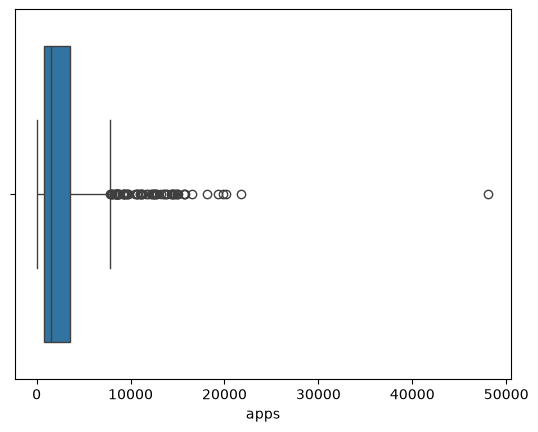

In [59]:
# do boxplot for the target using sns.boxplot
sns.boxplot(x=df['apps'])

In [60]:
# Check what is that oulier value appears in the boxplot
df[df['apps'] > 30000]


,university,private,apps,accept,enroll,top10perc,top25perc,f_undergrad,p_undergrad,outstate,room_board,books,personal,phd,terminal,s_f_ratio,perc_alumni,expend,grad_rate,private_bi
483,Rutgers at New Brunswick,No,48094,26330,4520,36,79,21401,3712,7410,4748,690,2009,90.0,95,19.5,19,10474,77,0


In [61]:
# Check the shape



In [62]:
# We can make a decision to drop the outlier, if we want! Test it!

# df = df[df['apps'] < 30000]
# df.shape

## EDA: What else do we want to explore?
---

In [63]:
# show main descriptive statistics of the dataframe
df.describe()

,apps,accept,enroll,top10perc,top25perc,f_undergrad,p_undergrad,outstate,room_board,books,personal,phd,terminal,s_f_ratio,perc_alumni,expend,grad_rate,private_bi
count,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000
mean,2971.072193,2000.812834,774.645722,27.477273,55.762032,3684.203209,856.808824,10414.467914,4359.664439,549.352941,1340.082888,72.518717,79.613636,14.074332,22.839572,9601.622995,65.419786,0.727273
std,3853.784286,2433.325215,925.818866,17.470289,19.667573,4860.286376,1538.225229,3990.415313,1099.291586,167.004079,679.581960,16.315199,14.629166,3.894483,12.345254,5125.989711,17.142141,0.445660
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,300.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.000000,0.000000
25%,760.500000,588.000000,239.000000,15.000000,41.000000,986.750000,95.000000,7257.000000,3595.750000,451.500000,850.000000,62.000000,70.750000,11.500000,13.000000,6755.500000,53.000000,0.000000
50%,1543.500000,1108.000000,433.000000,23.000000,54.000000,1705.500000,350.500000,9937.500000,4194.500000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8354.500000,65.000000,1.000000
75%,3581.500000,2394.500000,878.500000,35.000000,69.000000,3911.000000,967.250000,12859.500000,5064.000000,600.000000,1692.500000,85.000000,92.000000,16.425000,31.000000,10787.500000,78.000000,1.000000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.000000,1.000000


In [64]:
# phd & grad rate exceed 100%, correct to make it 100 or remove that rows.
df.loc[df['phd'] > 100 , 'phd'] = 100
df.loc[df['grad_rate'] > 100 , 'grad_rate'] = 100



# or fix to make 100
# df['phd'] = np.minimum(df['phd'], 100)
# df['grad_rate'] = np.minimum(df['grad_rate'], 100)

In [65]:
# do another boxplot for the target



<Axes: xlabel='apps', ylabel='Count'>

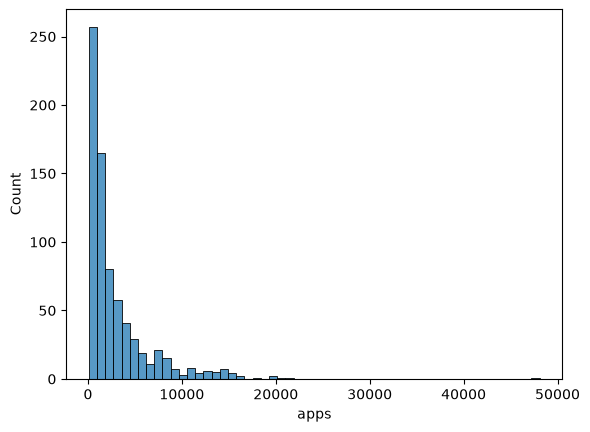

In [66]:
# do a histogram of the target to see the distrubution of the data

sns.histplot(df['apps'])

## EDA: Create Histograms of All Numerical Columns
---

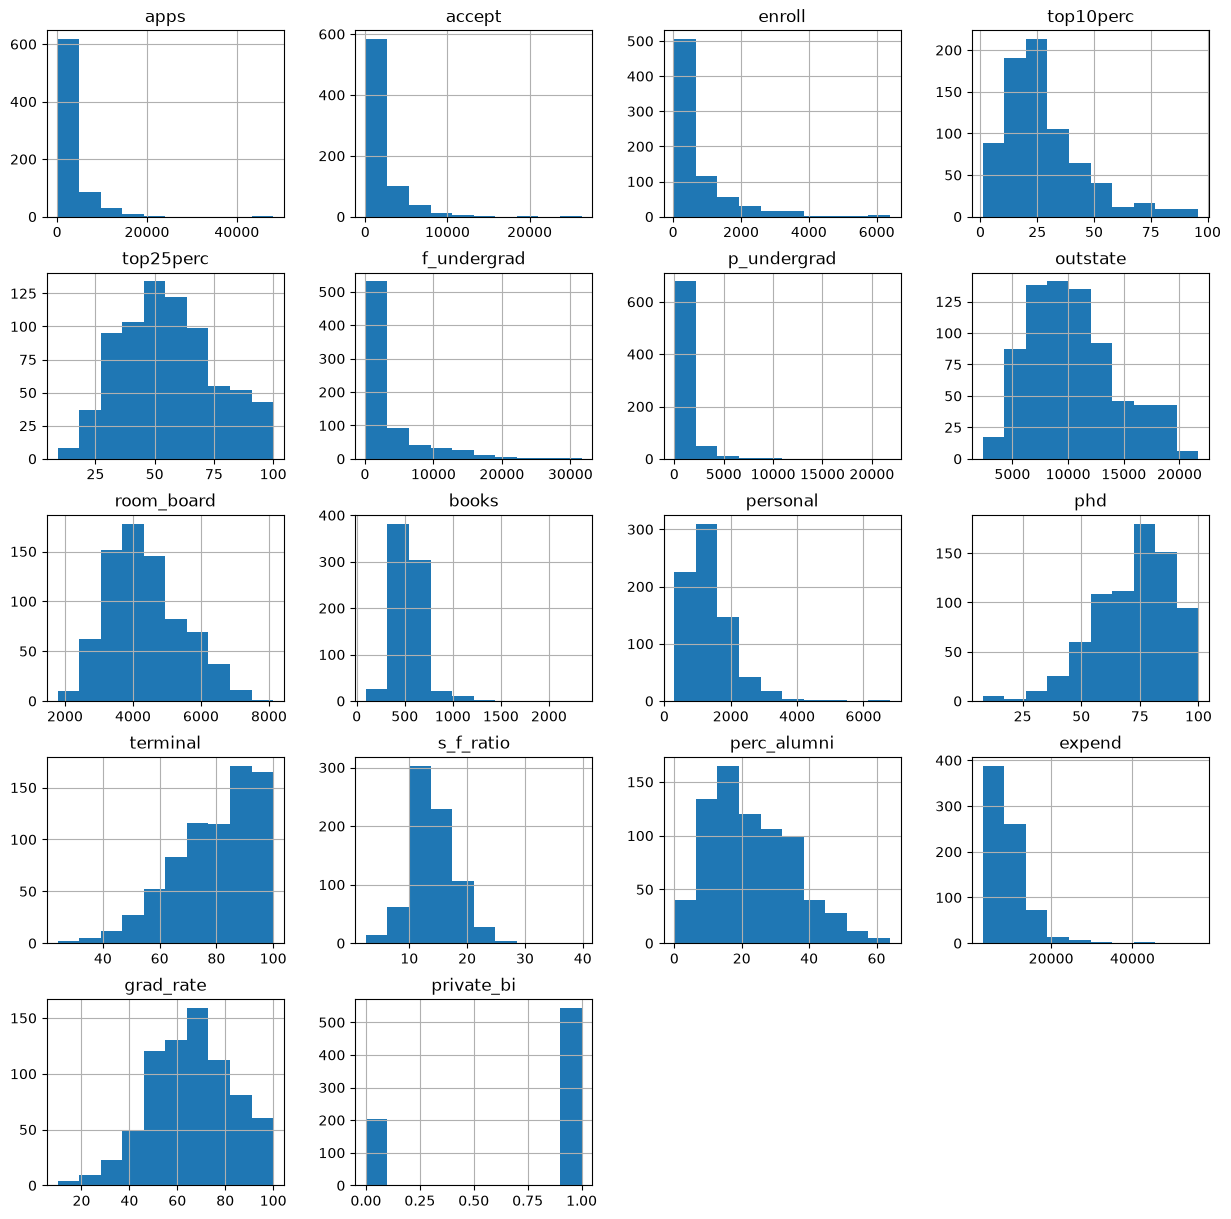

In [67]:
# do histogram for all the numeric columns

df.hist(figsize=(15,15));

## EDA: Plot a Heatmap of the Correlation Matrix
---

Heatmaps are an effective way to visually examine the correlational structure of your predictors. 

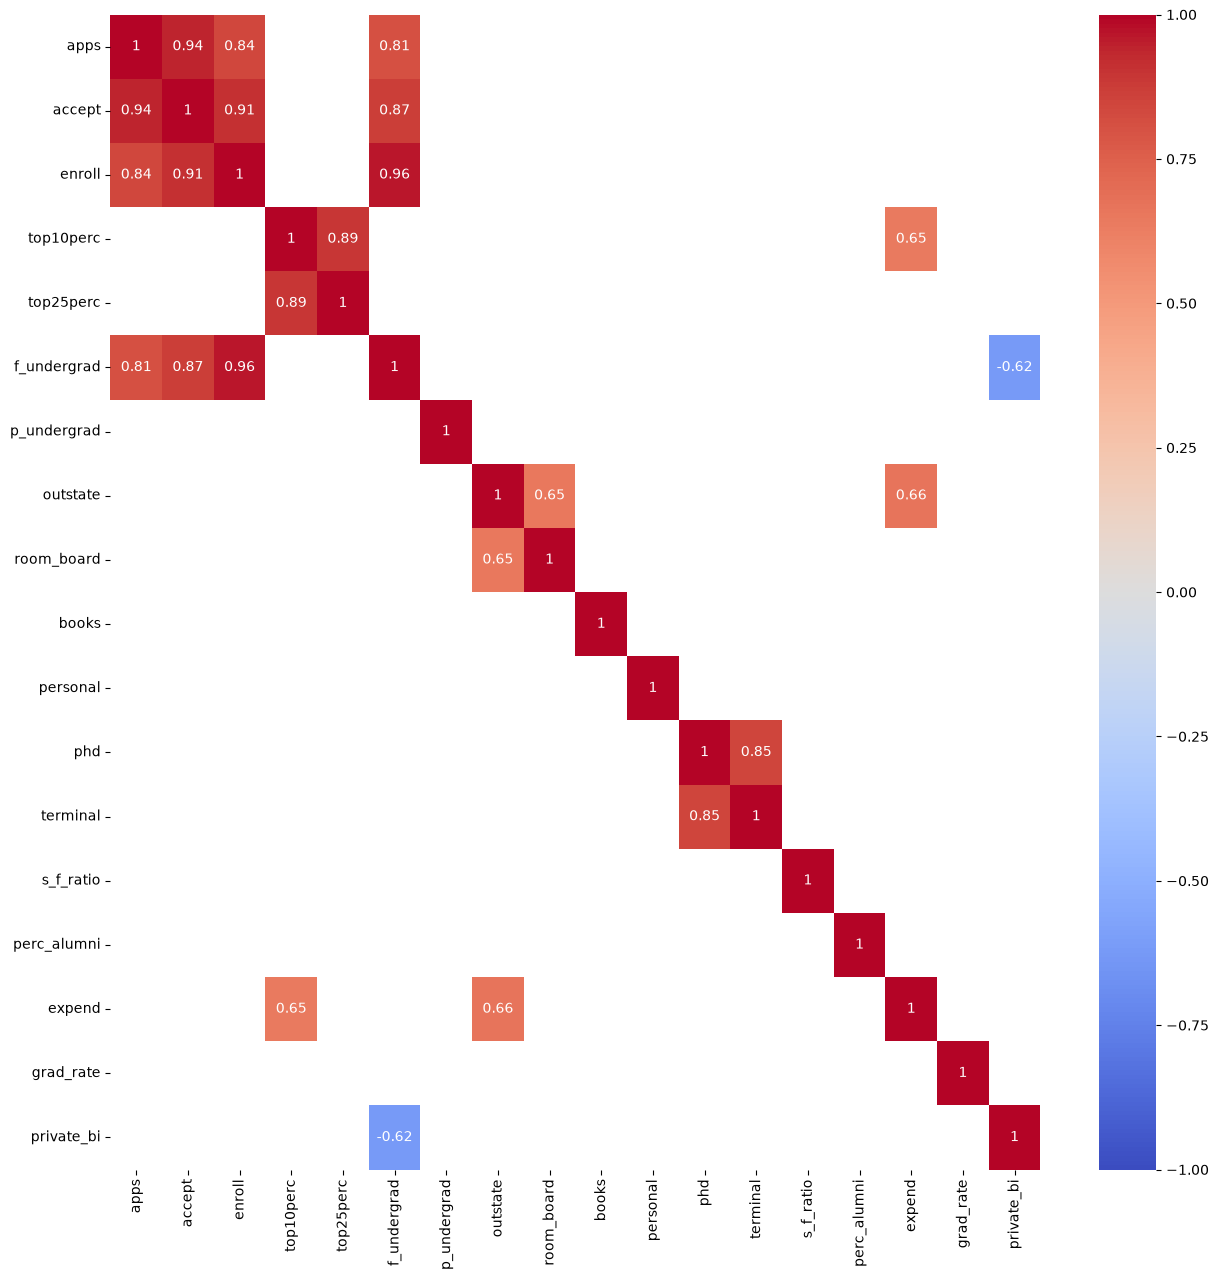

In [68]:
# Create a filtered correlation that shows values higher than a threshold
threshold = 0.6
filtered_corr = df.corr(numeric_only=True)
filtered_corr[filtered_corr.abs() < threshold] = np.nan

# plot the correlation heatmap
plt.figure(figsize=(15,15))
sns.heatmap(filtered_corr, 
            annot=True,
           vmin = -1,
           vmax = 1,
           cmap = 'coolwarm');

##### What if I just wanted to look at the correlation to `apps`?

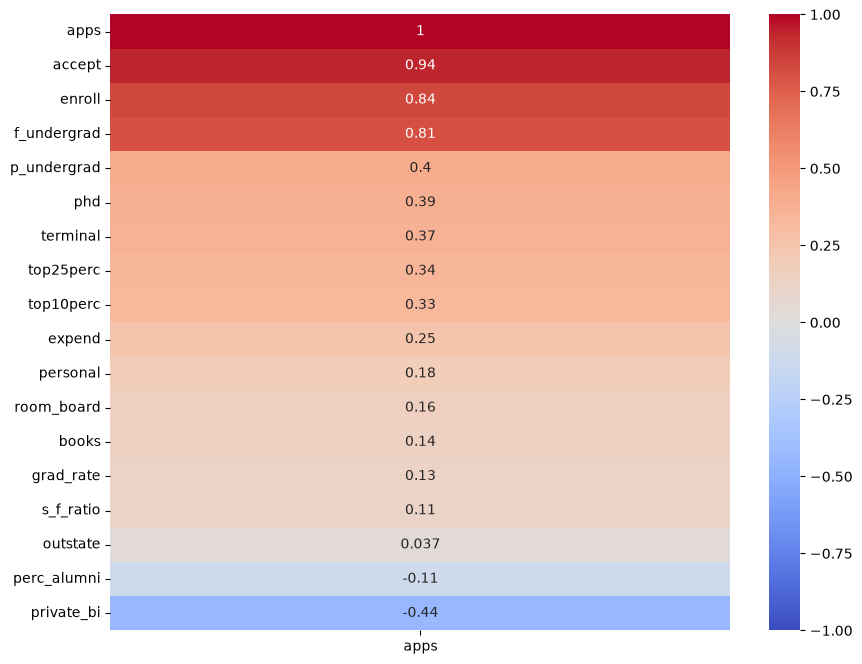

In [69]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True)[['apps']].sort_values(by='apps', ascending=False), 
            annot=True,
           vmin=-1,
           vmax=1,
           cmap = 'coolwarm');

## EDA: Use seaborn's `.pairplot()` method to create scatterplots 
---

Let's create a pairplot to see how some of our stronger predictors correlate to our target (`apps`). Instead of creating a pairplot of the entire DataFrame, we can use the `y_vars` and `x_vars` params to get a smaller subset.

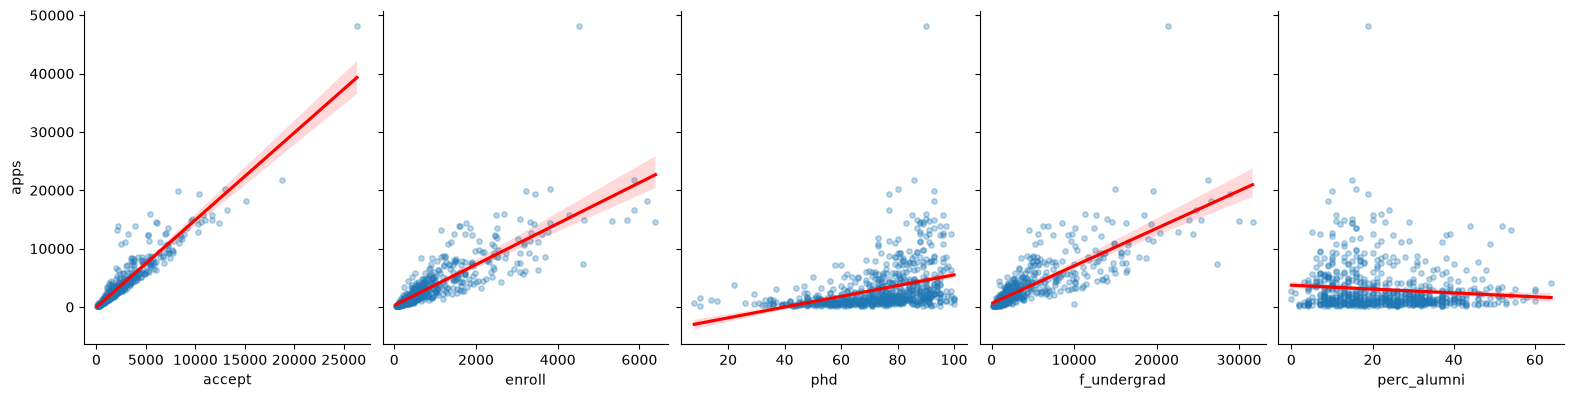

In [70]:
sns.pairplot(df, x_vars=['accept', 'enroll', 'phd', 'f_undergrad', 'perc_alumni'], 
             y_vars=['apps'],
             height=4,            # 👈 Makes each plot taller
             aspect=0.8,          # 👈 Adjusts the width proportion
             kind='reg',          # 👈 Automatically injects a linear regression line
             plot_kws={
                'scatter_kws': {
                    'alpha': 0.3, # 👈 Makes points semi-transparent to reveal data density
                    's': 15       # 👈 Shrinks dot size so thousands of rows don't blob together
                },
                'line_kws': {'color': 'red'} # Makes the linear assumption highly visible
             })
 

Let's create a pairplot to see how all predictors correlate to our target (`apps`). 

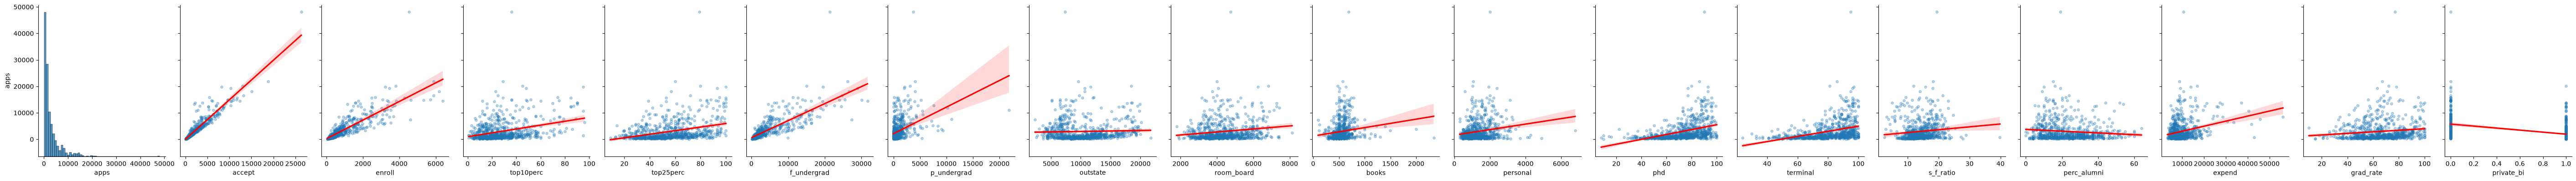

In [71]:
sns.pairplot(
    df, 
    x_vars=df.select_dtypes(include=['number']).columns.tolist(), 
    y_vars=['apps'],
    height=4,            # 👈 Makes each plot taller
    aspect=0.8,          # 👈 Adjusts the width proportion
    kind='reg',          # 👈 Automatically injects a linear regression line
    plot_kws={
        'scatter_kws': {
            'alpha': 0.3, # 👈 Makes points semi-transparent to reveal data density
            's': 15       # 👈 Shrinks dot size so thousands of rows don't blob together
        },
        'line_kws': {'color': 'red'} # Makes the linear assumption highly visible
    }
)


# Model Prep

## Model Prep: Create our features matrix (`X`) and target vector (`y`)
---

What should our features be?

The `apps` column is our label: the number of applications received by that university.

X will be dataframe without those columns:
```python
['university', 'accept', 'enroll', 'apps','private']
```
In the cell below, create your `X` and `y` variables.

In [72]:
X = df.drop(columns=['university', 'accept', 'enroll', 'apps','private'])
y=df['apps']

In [73]:
X.head(2)

,top10perc,top25perc,f_undergrad,p_undergrad,outstate,room_board,books,personal,phd,terminal,s_f_ratio,perc_alumni,expend,grad_rate,private_bi
0,23,52,2885,537,7440,3300,450,2200,70.0,78,18.1,12,7041,60,1
1,16,29,2683,1227,12280,6450,750,1500,29.0,30,12.2,16,10527,56,1


## Model Prep: Train/test split
---

We always want to have a holdout set to test our model. Use the `train_test_split` function to split our `X` and `y` variables into a training set and a holdout set.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.20, random_state=42)


## Model Prep: Scaling
---

In the cell below, fit a `StandardScaler` to `X_train` and use it to transform both `X_train` and `X_test`. This is especially important when we learn about `Ridge` and `Lasso` next week!

In [75]:
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)


## Model Instantiate
---


In [76]:
lr = LinearRegression()


## Model Evaluation: Scoring
---

Use `.score` to evaluate the model.

In [77]:
lr.fit(X_train, y_train)

print(f'training r2 score = {lr.score(X_train,y_train)}')
print(f'test r2 score = {lr.score(X_test,y_test)}')

training r2 score = 0.8362189151854068
test r2 score = 0.6032938999463286


## Model Evaluation: LINE Assumptions
---

* 1. Linearity: The relationship between predictors (\(X\)) and the target (\(Y\)) must be a straight line.
* 2. Independence: Prediction errors (residuals) must not be correlated with each other (e.g., avoid time-series tracking).
  3. Normality: The errors (residuals) follow a Normal distribution with mean 0
  4. Homoscedasticity: Prediction errors must maintain a constant variance across all levels of the predictors.
  5. No Multicollinearity: Independent variables (\(X\)) must not perfectly correlate with or predict each other

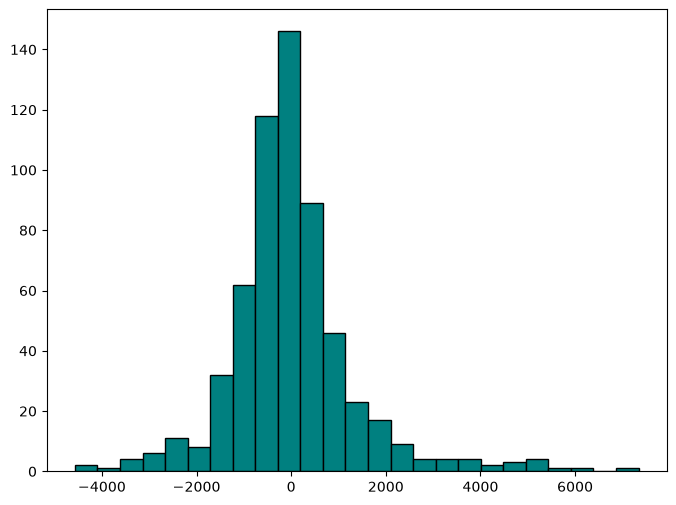

In [78]:
# N - Normality of errors
y_pred = lr.predict(X_train)
resids = y_train - y_pred

plt.figure(figsize = (8, 6))
plt.hist(resids, bins = 25, color = 'teal', edgecolor = 'black');

# Fine

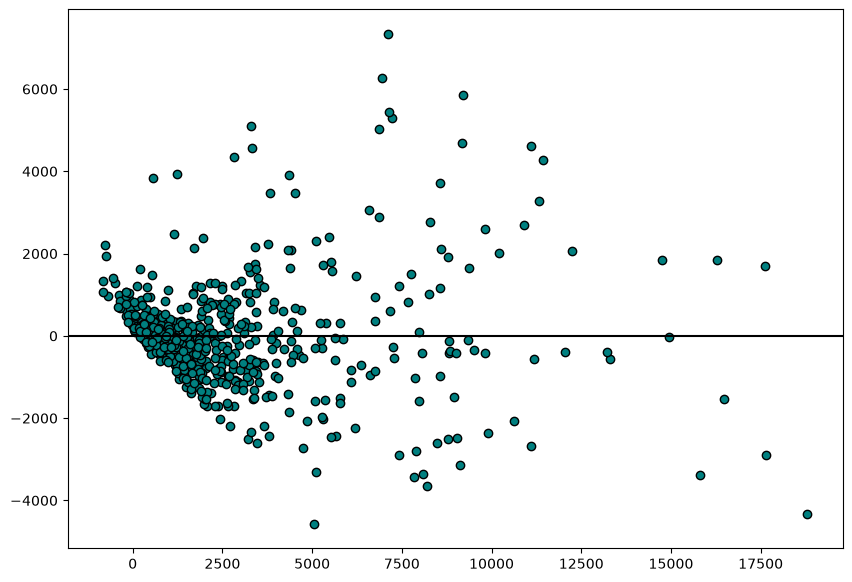

In [79]:
# E - Equal variance of errors
# Residual plot
plt.figure(figsize = (10, 7))
plt.scatter(y_pred, resids, color = 'teal', edgecolor = 'black')
plt.axhline(0, color = 'black');

# Heteroscedasticity (!!)

* #### Variance of the dependent variable varies and is not constant across the entire dataset.
    - What do we do? One option is to transform our dependent variable.
    - A common transformation is to simply take the log of the dependent variable
        * Note: If target has value less than 0 then use yeo-johnson power transformer instead of log


In [80]:
X.head(1)

,top10perc,top25perc,f_undergrad,p_undergrad,outstate,room_board,books,personal,phd,terminal,s_f_ratio,perc_alumni,expend,grad_rate,private_bi
0,23,52,2885,537,7440,3300,450,2200,70.0,78,18.1,12,7041,60,1


In [81]:
y_log = np.log(df['apps'])


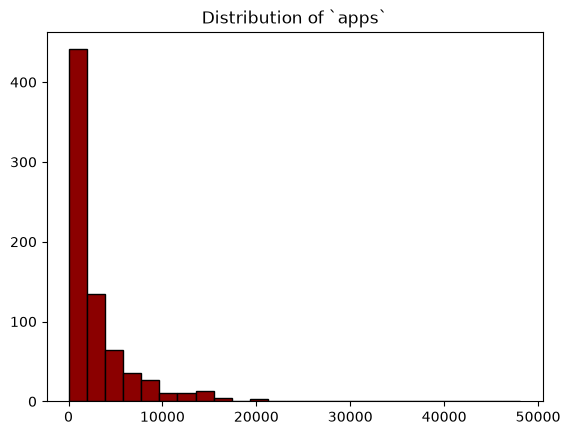

In [82]:
# What did this just do?
plt.hist(y, bins = 25, color = 'darkred', edgecolor = 'black')
plt.title('Distribution of `apps`');

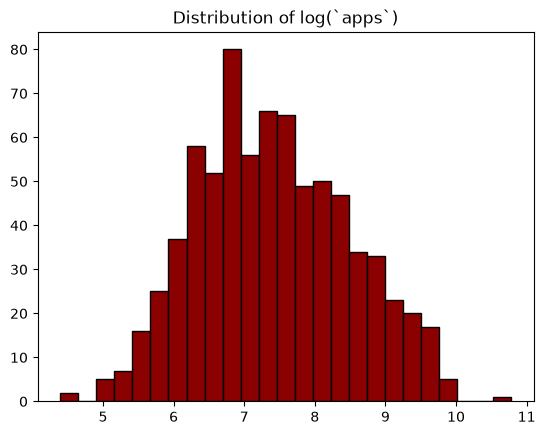

In [83]:
plt.hist(y_log, bins = 25, color = 'darkred', edgecolor = 'black')
plt.title('Distribution of log(`apps`)');

## **Note**
> Logarithmic transformation is a convenient means of transforming a highly skewed variable into a more normalized dataset.

* #### Split the data again using target transformed y_log.


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=.20,random_state = 42)

In [85]:
# fit standard scaler on X_train and transform to both X_train and X_test
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [87]:
lr_log = LinearRegression()
lr_log.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0.03, 0.07, 0.51,..., 0.13, 0.16,-0.29]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.386
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[55.95,42.33,26.53,...,10.7 , 9.34, 7.08]"


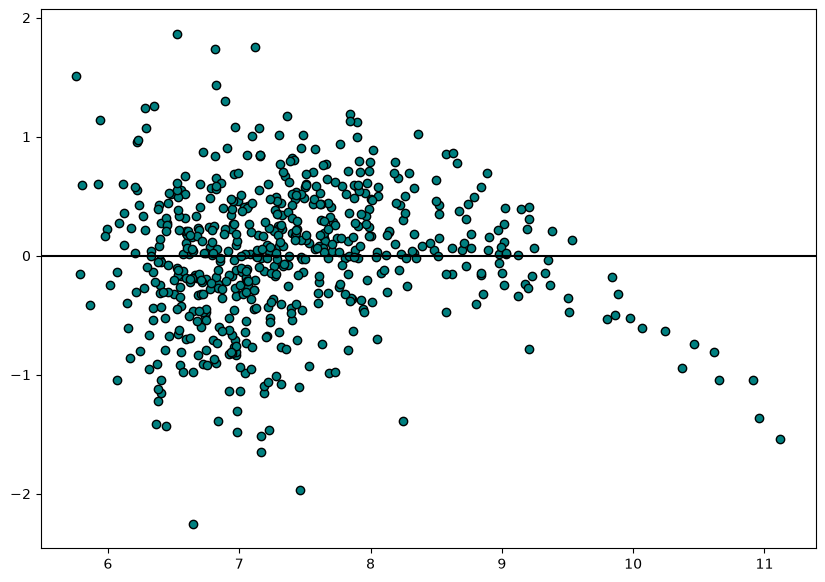

In [88]:
y_pred = lr_log.predict(X_train)
resids = y_train - y_pred


# E - Equal variance of errors
# Residual plot
plt.figure(figsize = (10, 7))
plt.scatter(y_pred, resids, color = 'teal', edgecolor = 'black')
plt.axhline(0, color = 'black');

In [89]:
# train r2 score after doing log target
lr_log.score(X_train,y_train)


0.7126156467476257

In [90]:
# test r2 score after doing log target

lr_log.score(X_test,y_test)

0.7519073752271472

### 😔

## Let's say that this model DID actually perform better... what do I need to remember to do to make predictions?

## Model Prediction:
---

In [93]:
# You must use the exponential to "undo" our log transformation!
y_pred[:5]


array([7.56292006, 7.26904255, 7.90059842, 6.68543858, 7.06667318])

In [94]:
y_pred_final = np.exp(y_pred)
y_pred_final[:5]

array([1925.45977976, 1435.175689  , 2698.89693076,  800.66175499,
       1172.24170369])

<div style="background-color: #f0f7ff; border-left: 5px solid #0066cc; padding: 15px; border-radius: 4px; margin: 20px 0;">
    <h3 style="color: #0066cc; margin: 0 0 5px 0; font-family: sans-serif; font-size: 18px; font-weight: bold;">
        🏁 End of Part One
    </h3>
    <p style="color: #334e68; margin: 0; font-family: sans-serif; font-size: 14px;">
        Data cleaning, exploratory visualizations, feature transformation,  and basic modeling Complete.
    </p>
</div>



# Enhance Modeling:

## 1. EDA: Check Skewness
---

Use the function that you created earlier in previous lab to check skewness

In [95]:
# import myutil script file to use the skew functions we created
import myutil


In [110]:
# create a skewness table

skew_tbl = myutil.evaluate_skewness(df,filter_result=True)
skew_tbl

Note: Skewness will be null if a column contains any null value


,Feature,Skewness Type,Skewness Value,Skewness level,Recommendation
0,apps,Right-Skewed,3.80,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
1,accept,Right-Skewed,3.47,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
2,enroll,Right-Skewed,2.70,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
3,top10perc,Right-Skewed,1.41,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
4,f_undergrad,Right-Skewed,2.62,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
5,p_undergrad,Right-Skewed,5.71,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
6,books,Right-Skewed,3.49,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
7,personal,Right-Skewed,1.79,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
8,expend,Right-Skewed,3.54,Highly skewed,"Log1p, Box-Cox or Yeo-Johnson"
9,outstate,Right-Skewed,0.51,Moderately skewed,"Log1p, Box-Cox or Yeo-Johnson"


In [111]:
# list all columns that doesn't have skewness

num_cols_no_skew = ['top25perc','room_board','grad_rate']
num_cols_no_skew

['top25perc', 'room_board', 'grad_rate']

In [112]:
# list all columns that have skewness

num_cols_skew = skew_tbl['Feature'].to_list()
num_cols_skew 

['apps',
 'accept',
 'enroll',
 'top10perc',
 'f_undergrad',
 'p_undergrad',
 'books',
 'personal',
 'expend',
 'outstate',
 'phd',
 'terminal',
 's_f_ratio',
 'perc_alumni']

In [113]:
# check skewness before and after

myutil.check_skew_before_after(skew_tbl,df,'yeo-johnson')

,Feature,Skew Before,Skew After
0,apps,3.80,0.01
1,accept,3.47,0.01
2,enroll,2.70,0.02
3,top10perc,1.41,0.01
4,f_undergrad,2.62,0.04
5,p_undergrad,5.71,-0.02
6,books,3.49,0.07
7,personal,1.79,-0.00
8,expend,3.54,-0.03
9,outstate,0.51,-0.02


* Important: remove the target column from the skew_cols


In [114]:
# Important: remove the target column from the skew_cols

num_cols_skew.remove('apps')
num_cols_skew

['accept',
 'enroll',
 'top10perc',
 'f_undergrad',
 'p_undergrad',
 'books',
 'personal',
 'expend',
 'outstate',
 'phd',
 'terminal',
 's_f_ratio',
 'perc_alumni']

## 2. Model Prep: Using Pipeline all the way 
---

## Specify Features and Target 
---

In [115]:
# specify the X and the y (if y needs log or power then transform it here)
X = df.drop(columns=['university', 'accept', 'enroll', 'apps','private_bi'])
y_log = np.log(df['apps'])

X.head(2)
# or if you want to use powertranfromer to transform y
# pt=PowerTransformer(method='yeo-johnson')
# y_log = pt.fit_transform(df[['apps']])

,private,top10perc,top25perc,f_undergrad,p_undergrad,outstate,room_board,books,personal,phd,terminal,s_f_ratio,perc_alumni,expend,grad_rate
0,Yes,23,52,2885,537,7440,3300,450,2200,70.0,78,18.1,12,7041,60
1,Yes,16,29,2683,1227,12280,6450,750,1500,29.0,30,12.2,16,10527,56


In [116]:
# List of columns that contains skewness
print(num_cols_no_skew)
print(num_cols_skew)

# notice that we need to remove the columns that was excluded from X features

['top25perc', 'room_board', 'grad_rate']
['accept', 'enroll', 'top10perc', 'f_undergrad', 'p_undergrad', 'books', 'personal', 'expend', 'outstate', 'phd', 'terminal', 's_f_ratio', 'perc_alumni']


In [117]:
num_cols_skew = ['top10perc', 'f_undergrad', 'p_undergrad', 'books', 'personal', 'expend', 'outstate', 'phd', 'terminal', 's_f_ratio', 'perc_alumni']


## Split Train and Test
---

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=.20,random_state = 42)


## Pipeline Prepare
---

In [119]:
# ==========================================
# 1. DEFINING SEPARATE PREPROCESSING SUB-PIPELINES
# ==========================================
# Sub-Pipeline A: For standard numeric data
normal_numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


# Sub-Pipeline B: For heavily skewed numeric data (uses a box-cox/yeo-johnson power transform)
skewed_numeric_transformer = Pipeline(steps=[
    ('power',PowerTransformer(method='yeo-johnson',standardize=False)),
    ('scaler',StandardScaler())
])

# Sub-Pipeline C: For regular distinct categories Use OneHotEncoder
nominal_transformer = Pipeline(steps=[
    ('onehot',OneHotEncoder(drop=None, handle_unknown='ignore',sparse_output=False)),
    ('scaler',StandardScaler())
])



# ==========================================
# 2. Meging All the Columns WITH COLUMNTRANSFORMER
# ==========================================
preprocessor =  ColumnTransformer(
    transformers=[
        ('norm_num',normal_numeric_transformer,num_cols_no_skew),
        ('skew_num',skewed_numeric_transformer,num_cols_skew),
        ('nom_cat',nominal_transformer,['private'])
    ],
    remainder='drop' # drop any columns not mentioned here. Use 'passthrough' to keep them
)       


In [120]:
# ==========================================
# 3. Building The Full Pipeline
#    3.1 Linear Regression
# ==========================================
# Build the main pipeline containing the preprocessor block and model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',LinearRegression())
])


In [121]:
full_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['private','top10perc','top25perc',...,'perc_alumni','expend','grad_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('norm_num', ...), ('skew_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [122]:
print(full_pipeline.score(X_train,y_train))
print(full_pipeline.score(X_test,y_test))


0.8609334133229842
0.8489116974636377


In [123]:
# ==========================================
# 3. Building The Full Pipeline
#    3.2 RidgeCV Regression
# ==========================================
# Build the main pipeline containing the preprocessor block and model
full_pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',RidgeCV(alphas=np.logspace(-3,3,100) , cv=5))
])
full_pipeline_ridge.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['private','top10perc','top25perc',...,'perc_alumni','expend','grad_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('norm_num', ...), ('skew_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

In [124]:
print(full_pipeline_ridge.score(X_train,y_train))
print(full_pipeline_ridge.score(X_test,y_test))


0.8608305601849449
0.8494178800852096


## Using GridsearchCV to do all the three models


In [125]:
# 4. Define the Parameter Grid
# Notice how we can swap out the entire 'regressor' step and its alpha weights!
param_grid=[
    {'preprocessor__nom_cat__onehot__drop':['first',None],
     'model':[LinearRegression()]
    },
    {'preprocessor__nom_cat__onehot__drop':[None],
     'model':[Ridge()],
     'model__alpha':np.logspace(-3,3,100)
    },
    {'preprocessor__nom_cat__onehot__drop':[None],
     'model':[Lasso(max_iter=1000)],
     'model__alpha':[0.01,0.1,1.0,10]
    }
]

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',LinearRegression())
])     
        
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1)

grid_search.fit(X_train,y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [LinearRegression()], 'preprocessor__nom_cat__onehot__drop': ['first', None]}, {'model': [Ridge()], 'model__alpha': array([1.0000...00000000e+03]), 'preprocessor__nom_cat__onehot__drop': [None]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and c

In [126]:
# 6. View Results

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}") # average score across CV validation folds
print(f"Train R2 Score: {grid_search.best_estimator_.score(X_train,y_train):.4f}")
print(f"Test R2 Score: {grid_search.best_estimator_.score(X_test,y_test):.4f}")

Best Parameters: {'model': Lasso(), 'model__alpha': 0.01, 'preprocessor__nom_cat__onehot__drop': None}
Best CV R2 Score: 0.8472
Train R2 Score: 0.8584
Test R2 Score: 0.8505


In [127]:
lr_pred = grid_search.predict(X_test)
lr_pred[:5]


array([7.75954511, 6.97257758, 9.01711036, 5.90100566, 7.09984885])

In [128]:
lr_pred_final = np.exp(lr_pred)
lr_pred_final[:5]


array([2343.83817799, 1066.96940332, 8242.92352632,  365.40475491,
       1211.78389976])

In [129]:
# what is grid search best_estimator_

grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['private','top10perc','top25perc',...,'perc_alumni','expend','grad_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('norm_num', ...), ('skew_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

# Save your model using joblib

In [130]:
import joblib

# 1. Save the entire GridSearch object (or just the best pipeline)
# It is best practice to save the '.best_estimator_' to keep the file clean
joblib.dump(grid_search.best_estimator_, 'my_model.pkl')


['my_model.pkl']

In [131]:
# ----------------------------------------------------
# 2. Later (in your production or testing script):
# ----------------------------------------------------
loaded_pipeline = joblib.load('my_model.pkl')

pred = loaded_pipeline.predict(X_test)
pred[:5]



array([7.75954511, 6.97257758, 9.01711036, 5.90100566, 7.09984885])

In [132]:
pred_final = np.exp(pred)
pred_final[:5]



array([2343.83817799, 1066.96940332, 8242.92352632,  365.40475491,
       1211.78389976])